# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 12     |  |
| :-------------|:-------------|
| Carsten Schroevers|6126634 |
| Pieter Otten| 6332463 |
| Pieter Broerse|6507840 |
| Planning Groep: 12     |Tijdstip / Tijdspanne  |
|---|---|
| Condensator is gebouwd | 12:30 |
| Capacitieve condensator is gebouwd | 17:30 |
| groep aanwezig 1| 10:30 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30 - 13:30 |
| Pauze 2| 15:30 - 16:00 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="IMG_1403.JPG" alt="schets student 1" width="400"/>

In [17]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def theoretische_capaciteit(e_r, A, d):
    e_0 = 8.85e-12
    C =  (e_0 * e_r * A) / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [18]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

import numpy as np

e_karton =1.66
d = 0.001
A = 0.01

C = theoretische_capaciteit(e_karton,A,d)

C_pf = C*10**12

print("Berekende capaciteit plaatcondensator groep 12 is: ", np.round(C_pf), " pF")



Berekende capaciteit plaatcondensator groep 12 is:  147.0  pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_1405.JPG)
![scope meting 2](IMG_1406.JPG)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 12| 147 pf | 0.74 V | 0.72 V | 143 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_1404.JPG)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die dielektrische constante of permittiviteit meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_1407.JPG)

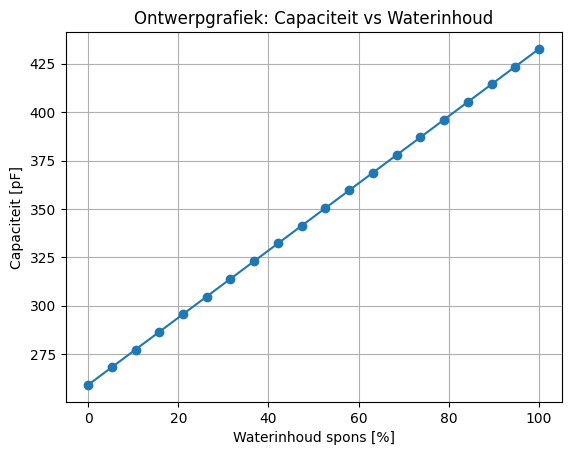

In [19]:
water_frac = np.linspace(0, 1, 20)  # 0 = droge spons, 1 = volledig verzadigd
epsilon_spons_droog = 1.5
epsilon_water = 80

d_1 = 0.04

epsilon_r = epsilon_spons_droog + water_frac * (epsilon_water - epsilon_spons_droog)

c_array = theoretische_capaciteit(epsilon_r, A, d_1)  
c_pf2 = c_array * 1e12

c_pf2_shifted = c_pf2 - c_pf2[0] + 259  

import matplotlib.pyplot as plt

plt.plot(water_frac*100, c_pf2_shifted, marker='o')
plt.xlabel("Waterinhoud spons [%]")
plt.ylabel("Capaciteit [pF]")
plt.title("Ontwerpgrafiek: Capaciteit vs Waterinhoud")
plt.grid(True)
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (V)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 260 | 2.6 |
| gemiddelde capaciteit|  345 |3.4 |
| maximale capaciteit| 430 | 4.2 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](IMG_1408.JPG)
![meting 2](IMG_1409.JPG)

## Opdracht 7: Plot de kalibratiegrafiek.

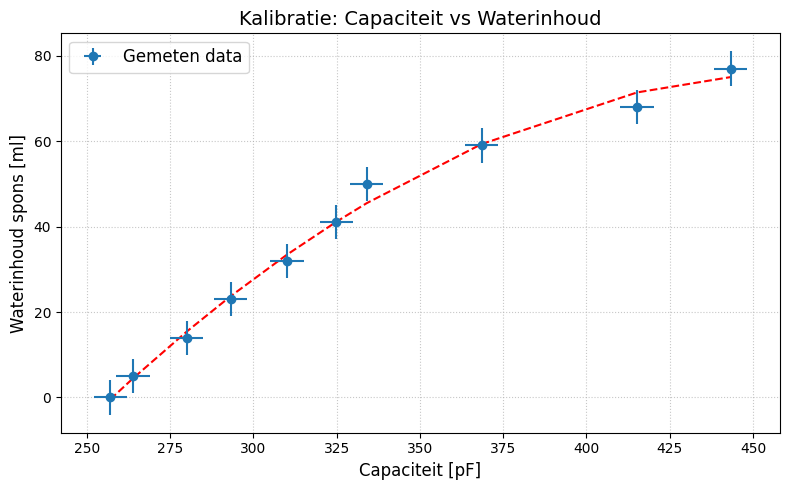

Bij een gemeten capacitantie van 300 pF is de geschatte waterinhoud 27.76 ml
[-1.75197786e-03  1.63192857e+00 -3.04136549e+02]


In [ ]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
from scipy.optimize import curve_fit


# Gemeten data
capacitance = np.array([257, 263.8, 280, 293.2, 310.1, 324.9, 334,368.5,415.2,443.3])
volume_ml = np.array([0, 5, 14, 23, 32, 41, 50, 59, 68, 77])
capacitance_error = 5
volume_error = 4
# Definieer een lineair model voor curve fit
def linear_model(x, a, b, c):
    return a * x**2 + b*x + c

# Curve fit
params, covariance = curve_fit(linear_model,capacitance, volume_ml)
a, b, c = params
fit_curve = linear_model(capacitance, a, b, c)

# Plotten
plt.figure(figsize=(8,5))
plt.plot(capacitance, fit_curve, color='red', linestyle='--',)
plt.xlabel("Capaciteit [pF]", fontsize=12)
plt.ylabel("Waterinhoud spons [ml]", fontsize=12)
plt.title("Kalibratie: Capaciteit vs Waterinhoud", fontsize=14)
plt.errorbar(capacitance, volume_ml, xerr=capacitance_error, yerr=volume_error, fmt='o', label='Gemeten data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

measured_c = 300 #pF
estimated_volume = linear_model(measured_c,*params)
print(f"Bij een gemeten capacitantie van {measured_c} pF is de geschatte waterinhoud {estimated_volume:.2f} ml")
print(params)



In [21]:
capacitance_nieuwe_spons = np.array([400]) #nF

estimated_volume = linear_model(capacitance_nieuwe_spons, *params)
print(estimated_volume)

[68.31842111]


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Door de dikte op een manier constant te houden blijft het verband linear, en zijn de metingen nauwkeuriger.
* De oppervlakte moet altijd op dezelfde lijn liggen, nu verschuift het steeds omdat we de bovenste laag steeds moeten optillen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](IMG_1410.JPG)

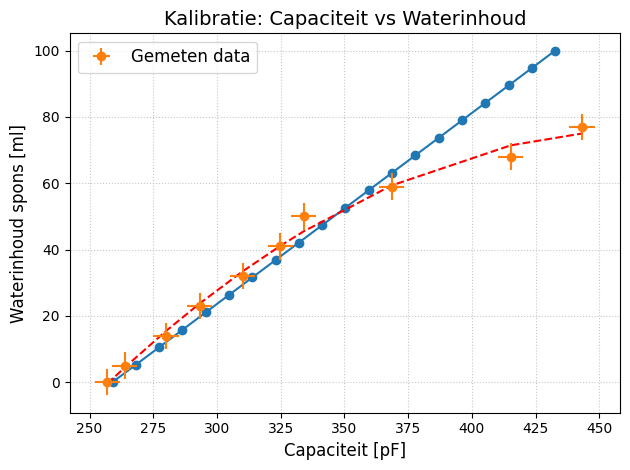

In [22]:
plt.plot(c_pf2_shifted ,water_frac*100, marker='o')
plt.xlabel("Waterinhoud spons [%]")
plt.ylabel("Capaciteit [pF]")
plt.title("Ontwerpgrafiek: Capaciteit vs Waterinhoud")
plt.grid(True)

plt.plot(capacitance, fit_curve, color='red', linestyle='--',)
plt.xlabel("Capaciteit [pF]", fontsize=12)
plt.ylabel("Waterinhoud spons [ml]", fontsize=12)
plt.title("Kalibratie: Capaciteit vs Waterinhoud", fontsize=14)
plt.errorbar(capacitance, volume_ml, xerr=capacitance_error, yerr=volume_error, fmt='o', label='Gemeten data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



## Opdracht 10: Vul hieronder de conclusie in.

Het doel van de sensor was het correct bepalen van het aantal ml in een spons door middel van de capaciteit. In dit geval is dat uitstekend gelukt, aangezien het aantal ml goed te bepalen is. Zoals te zien hierboven, wijkt de kalibratiegrafiek af van de verwachtte grafiek. Dit is te verklaren door het feit dat de dikte ook verandert als de spons erg nat is, waardoor de capaciteit nog sterker toeneemt. De kalibratie is wel gebaseerd op dit feit, en vandaar dat de kalibratie erg goed werkt. 



## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](IMG_1408.JPG)
![meting 2](IMG_1409.JPG)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

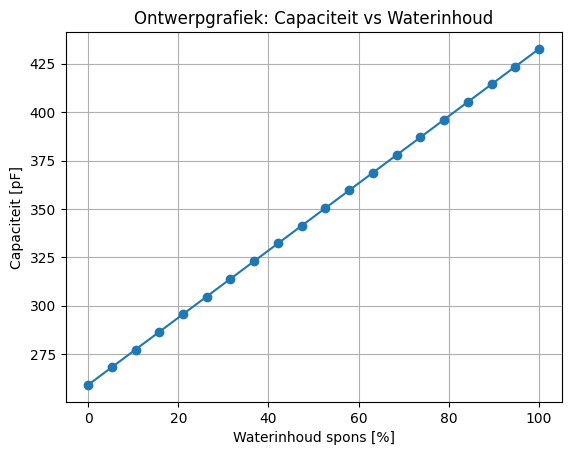

In [23]:
water_frac = np.linspace(0, 1, 20)  # 0 = droge spons, 1 = volledig verzadigd
epsilon_spons_droog = 1.5
epsilon_water = 80

d_1 = 0.04

epsilon_r = epsilon_spons_droog + water_frac * (epsilon_water - epsilon_spons_droog)

c_array = theoretische_capaciteit(epsilon_r, A, d_1)  
c_pf2 = c_array * 1e12

c_pf2_shifted = c_pf2 - c_pf2[0] + 259  

import matplotlib.pyplot as plt

plt.plot(water_frac*100, c_pf2_shifted, marker='o')
plt.xlabel("Waterinhoud spons [%]")
plt.ylabel("Capaciteit [pF]")
plt.title("Ontwerpgrafiek: Capaciteit vs Waterinhoud")
plt.grid(True)
plt.show()

#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_1405.JPG)
![scope meting 2](IMG_1406.JPG)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

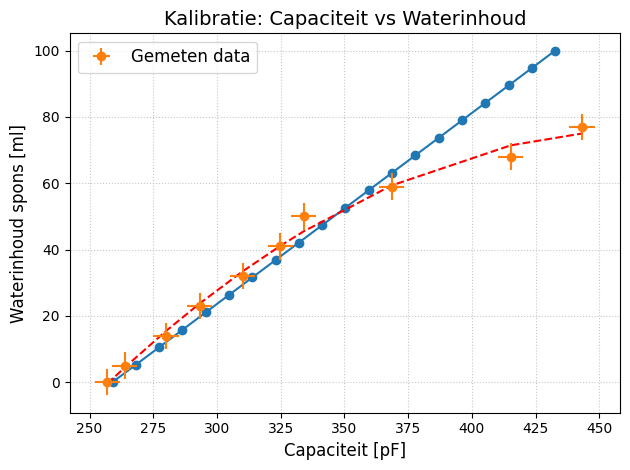

In [24]:
plt.plot(c_pf2_shifted ,water_frac*100, marker='o')
plt.xlabel("Waterinhoud spons [%]")
plt.ylabel("Capaciteit [pF]")
plt.title("Ontwerpgrafiek: Capaciteit vs Waterinhoud")
plt.grid(True)

plt.plot(capacitance, fit_curve, color='red', linestyle='--',)
plt.xlabel("Capaciteit [pF]", fontsize=12)
plt.ylabel("Waterinhoud spons [ml]", fontsize=12)
plt.title("Kalibratie: Capaciteit vs Waterinhoud", fontsize=14)
plt.errorbar(capacitance, volume_ml, xerr=capacitance_error, yerr=volume_error, fmt='o', label='Gemeten data')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


## Opdracht 10: Vul hieronder de conclusie in.

Het doel van de sensor was het correct bepalen van het aantal ml in een spons door middel van de capaciteit. In dit geval is dat uitstekend gelukt, aangezien het aantal ml goed te bepalen is. Zoals te zien hierboven, wijkt de kalibratiegrafiek af van de verwachtte grafiek. Dit is te verklaren door het feit dat de dikte ook verandert als de spons erg nat is, waardoor de capaciteit nog sterker toeneemt. De kalibratie is wel gebaseerd op dit feit, en vandaar dat de kalibratie erg goed werkt. 

